In [314]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [315]:
df = pd.read_csv('messy_customer_sales_data.csv')

In [316]:
df.sample(10)

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
4071,NaN,Amy Kennedy,f,43.0,Bangalore,2024-10-17,2025-04-04,36482.0,3.0,woodkenneth@example.net,7597026353,India
3217,CUST2350,Destiny Obrien,FEMALE,57.0,delhi,2021-09-19,2025-01-07,39634.0,7.0,johnnywells@example.net,7659296671,India
7070,CUST6993,Bradley Pacheco,M,67.0,bangalore,2023-05-06,2025-05-31,29627.0,9.0,juarezbrandy@example.net,9605578291,India
9816,CUST9947,Shannon Booker,FEMALE,32.0,mumbai,2022-04-04,2025-07-12,33077.0,5.0,wolfkimberly@example.org,1454324246,InDia
6456,CUST6442,James Johnson,male,32.0,kolkata,2022-11-11,NaN,35547.0,8.0,nathanrojas@example.org,1403891286,india
2495,CUST9068,Vicki Fry,female,40.0,hyderabad,2024-09-02,NaN,24826.0,6.0,stephaniebeck@example.net,4407568913,IND
8807,CUST1653,Amy Gordon,male,29.0,Chennai,2022-04-29,2025-03-07,26972.0,3.0,hfernandez@example.net,2381277840,InDia
9130,CUST3399,Robert Watkins,female,NaN,Kolkata,2023-07-16,2025-07-17,NaN,7.0,dennis11@example.net,2597366875,India
7157,CUST2226,Kimberly Smith,MALE,69.0,CHENNAI,2022-05-14,2025-05-04,32900.0,7.0,alyssa04@example.org,7045482135,IND
5218,CUST8414,Edgar Stevens,m,32.0,Delhi,2023-02-11,2025-08-16,33215.0,5.0,davisjanice@example.org,8101895313,India


In [317]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


In [318]:
np.round(df.describe())

,Purchase_Amount,Feedback_Score,Phone_Number
count,9179.0,9177.0,1.020000e+04
mean,29090.0,5.0,4.979974e+09
std,208697.0,3.0,2.902593e+09
min,-500.0,1.0,9.208990e+05
25%,12295.0,3.0,2.449157e+09
50%,24330.0,5.0,4.988639e+09
75%,37130.0,8.0,7.510448e+09
max,9999999.0,10.0,9.994402e+09


**There are outliers present in Purchase_Amount Column as it can be interpreted from the difference between maximum and mean values.**

**There is generous amount of null values present in the whole dataset**

In [319]:
df.isnull().sum()

Customer_ID           1023
Name                     0
Gender                1026
Age                    951
City                  1016
Signup_Date              0
Last_Purchase_Date    1012
Purchase_Amount       1021
Feedback_Score        1023
Email                    0
Phone_Number             0
Country                732
dtype: int64

In [320]:
df.shape

(10200, 12)

# Data Cleaning and Formatting

In [321]:
df['Customer_ID'].value_counts()

Customer_ID
CUST3374     2
CUST7749     2
CUST10800    2
CUST6588     2
CUST9062     2
            ..
CUST10204    1
CUST4647     1
CUST9548     1
CUST9966     1
CUST4812     1
Name: count, Length: 9000, dtype: int64

In [322]:
df = df.drop_duplicates()
df.dropna(subset = ['Customer_ID'] , inplace = True)

In [323]:
df['Gender'].unique()

array(['m ', 'M', 'F', 'FEMALE', 'f ', 'male', 'MALE', 'female', nan],
      dtype=object)

In [324]:
df["Gender"] = df["Gender"].str.strip()

In [325]:
df["Gender"].unique()

array(['m', 'M', 'F', 'FEMALE', 'f', 'male', 'MALE', 'female', nan],
      dtype=object)

In [326]:
df['Gender'] = df['Gender'].replace({'m': 'M', 'male': 'M', 'MALE': 'M'})
df['Gender'] = df['Gender'].replace({'f': 'F', 'female': 'F', 'FEMALE': 'F'})

In [327]:
df["Gender"].unique()

array(['M', 'F', nan], dtype=object)

In [328]:
df["Gender"].fillna(df['Gender'].mode()[0] , inplace = True)

In [329]:
df["Gender"].unique()

array(['M', 'F'], dtype=object)

In [330]:
df["Gender"].value_counts()

Gender
M    5063
F    4100
Name: count, dtype: int64

In [331]:
df["Age"].unique()

array(['52.0', '51.0 years', '62.0', '40.0', '41.0', nan, '18.0',
       '43.0 years', '40.0 years', '26.0', '32.0', '22.0', '59.0', '65.0',
       '61.0', '31.0', '54.0 years', '55.0', '69.0', '61.0 years', '24.0',
       '63.0', '19.0', '50.0', '56.0', '36.0', '68.0', '43.0', '38.0',
       '27.0', '57.0 years', '23.0', '25.0', '66.0', '28.0', '30.0',
       '46.0', '48.0', '20.0', '37.0', '67.0', '51.0', '35.0', '58.0',
       '29.0', 'nan years', '39.0', '49.0', '47.0', '42.0', '44.0',
       '64.0', '53.0', '60.0', '59.0 years', '45.0', '21.0', '34.0',
       '54.0', '48.0 years', '46.0 years', '33.0', '57.0', '30.0 years',
       '58.0 years', '35.0 years', '34.0 years', '69.0 years', '250',
       '19.0 years', '27.0 years', '53.0 years', '65.0 years',
       '66.0 years', '44.0 years', '49.0 years', '25.0 years',
       '23.0 years', '62.0 years', '41.0 years', '33.0 years',
       '28.0 years', '22.0 years', '20.0 years', '42.0 years',
       '45.0 years', '3', '63.0 years', '

In [332]:
import re
def age_extraction(age):
    num = re.findall('\d+' , str(age))
    if len(num) > 0:
        return num[0]
    else :
        return num

df['Age'] = df['Age'].apply(lambda x : age_extraction(x))
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,M,52,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,F,40,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,F,41,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10194,CUST6146,Cody Thompson,F,40,NaN,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,India
10195,CUST10767,Robert Lewis,F,35,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10197,CUST6315,Joshua Martinez,M,25,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,F,55,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia


In [333]:
# First handle string replacements
df["Age"] = df["Age"].str.replace('nan years' , 'nan')
df["Age"] = df["Age"].str.replace('nan' , '0' )

# Convert to numeric first (this handles any remaining string values and creates proper NaN)
df["Age"] = pd.to_numeric(df["Age"], errors='coerce')

# Fill NaN values with mean BEFORE converting to integer
df["Age"].fillna(df["Age"].mean(), inplace=True)

# Now convert to integer (no NaN values remain)
df["Age"] = df["Age"].astype('int64')

In [334]:
df.sample(10)

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
9037,CUST3046,Brent Reed,M,43,BANGALORE,2023-06-10,2025-01-03,34363.0,7.0,harrisamy@example.net,807131309,InDia
9499,CUST8378,Mary Morgan,F,38,HYDERABAD,2021-04-16,2024-11-06,14947.0,10.0,eric35@example.net,8487134327,IND
8258,CUST2440,Joseph Lopez,M,65,CHENNAI,2022-09-12,2025-03-28,36921.0,5.0,rhondaking@example.com,4125383974,InDia
8207,CUST9455,Katelyn Harper,M,61,MUMBAI,2021-02-03,2025-02-09,NaN,1.0,misty14@example.net,2692663708,India
1561,CUST9538,Robin Walker,M,31,Delhi,2022-11-19,2025-08-19,NaN,9.0,ihall@example.net,2086617559,NaN
6759,CUST8679,Dillon Brown,F,43,Chennai,2023-07-15,NaN,3433.0,2.0,johnnyrodriguez@example.org,501050086,India
8884,CUST7012,Sheila Stephens,M,43,bangalore,2023-01-20,2025-06-12,10634.0,1.0,david60@example.org,275548973,India
221,CUST5404,Donna Mejia,M,62,Kolkata,2022-05-15,2025-02-18,33622.0,7.0,bellchristopher@example.net,2571099747,India
1624,CUST5657,Audrey Taylor,M,21,NaN,2022-05-14,2025-01-02,36151.0,2.0,emilystark@example.com,6531182938,india
98,CUST10803,Shannon Stokes,M,29,kolkata,2024-07-27,2025-01-27,11432.0,10.0,lori07@example.org,4739188153,India


In [335]:
df["City"].value_counts()

City
Kolkata       737
Mumbai        720
Chennai       700
Delhi         696
Bangalore     689
Hyderabad     671
CHENNAI       370
hyderabad     352
bangalore     350
DELHI         349
MUMBAI        348
KOLKATA       343
HYDERABAD     340
delhi         330
BANGALORE     325
mumbai        316
chennai       307
kolkata       303
Name: count, dtype: int64

In [336]:
df["City"] = df["City"].str.replace('kolkata' , 'Kolkata')
df["City"] = df["City"].str.replace('KOLKATA' , 'Kolkata')
df["City"] = df["City"].str.replace('mumbai' , 'Mumbai')
df["City"] = df["City"].str.replace('MUMBAI' , 'Mumbai')
df["City"] = df["City"].str.replace('chennai' , 'Chennai')
df["City"] = df["City"].str.replace('CHENNAI' , 'Chennai')
df["City"] = df["City"].str.replace('delhi' , 'Delhi')
df["City"] = df["City"].str.replace('DELHI' , 'Delhi')
df["City"] = df["City"].str.replace('hyderabad' , 'Hyderabad')
df["City"] = df["City"].str.replace('HYDERABAD' , 'Hyderabad')
df["City"] = df["City"].str.replace('bangalore' , 'Bangalore')
df["City"] = df["City"].str.replace('BANGALORE' , 'Bangalore')

In [337]:
df["City"].value_counts()

City
Mumbai        1384
Kolkata       1383
Chennai       1377
Delhi         1375
Bangalore     1364
Hyderabad     1363
Name: count, dtype: int64

In [338]:
df.sample(10)

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
8770,CUST1019,Carla Gray,F,41,NaN,2024-07-14,2025-06-12,NaN,1.0,alan00@example.net,7661418013,India
4319,CUST10921,Kevin Camacho,F,29,Chennai,2024-02-24,2025-07-29,23155.0,NaN,catherine73@example.org,6576461992,India
7650,CUST6217,Elizabeth Brown,M,64,Kolkata,2023-03-02,2024-11-01,15345.0,7.0,kyle02@example.net,2470772357,IND
7838,CUST8947,Jeffery Jennings,F,36,Chennai,2022-06-20,2024-12-26,26832.0,4.0,garmstrong@example.net,1076743933,India
3688,CUST10663,Michael Gonzalez,F,46,Bangalore,2022-05-29,2024-11-03,47422.0,3.0,danamitchell@example.net,2472227713,InDia
8697,CUST1541,Sean Moore,F,36,Chennai,2024-04-07,2025-05-09,36764.0,9.0,wattsstephanie@example.net,766798899,India
4545,CUST9151,Jessica Williams,M,40,Bangalore,2021-08-28,NaN,23663.0,7.0,dharris@example.net,9496689131,India
1279,CUST3079,Ronald Marshall,M,67,Bangalore,2025-05-26,2025-04-29,1856.0,5.0,gramos@example.org,1050949772,India
9608,CUST1052,Crystal Robinson,F,26,Kolkata,2023-04-11,2025-04-07,44243.0,NaN,christianjohnson@example.org,1436917159,india
5152,CUST8852,Melissa Nguyen DVM,M,32,Mumbai,2025-01-25,2025-04-19,49695.0,8.0,martinheather@example.com,6783454604,India


In [339]:
df.describe()

,Age,Purchase_Amount,Feedback_Score,Phone_Number
count,9163.000000,8.237000e+03,8259.000000,9.163000e+03
mean,43.576994,2.954660e+04,5.481172,4.984675e+09
std,15.315899,2.202503e+05,2.864372,2.902568e+09
min,3.000000,-5.000000e+02,1.000000,9.208990e+05
25%,32.000000,1.228600e+04,3.000000,2.449018e+09
50%,43.000000,2.427500e+04,5.000000,5.001842e+09
75%,55.000000,3.710100e+04,8.000000,7.510713e+09
max,250.000000,9.999999e+06,10.000000,9.994402e+09


<Axes: ylabel='Age'>

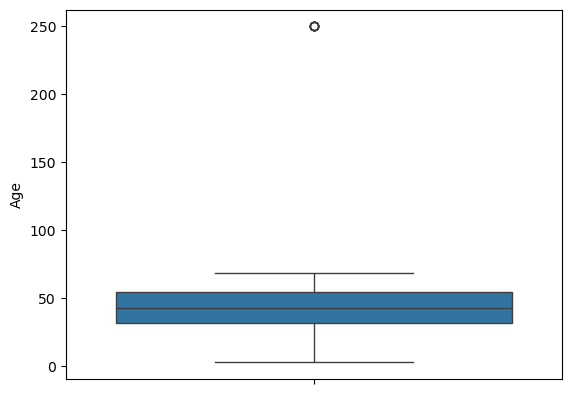

In [340]:
sns.boxplot(df["Age"])

In [341]:
df["Age"] = df["Age"].replace(250 , df["Age"].mean())

<Axes: ylabel='Age'>

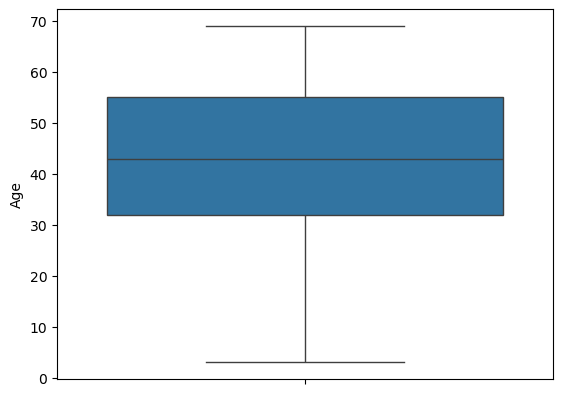

In [342]:
sns.boxplot(df["Age"])

In [343]:
df.sample(10)

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
9225,CUST8409,Brian Taylor,M,64.0,Bangalore,2022-02-08,2025-09-28,16488.0,10.0,littleanthony@example.org,7539206026,India
1917,CUST10891,Stephanie Holmes,F,60.0,Mumbai,2020-11-12,2024-10-15,35498.0,4.0,victor92@example.org,5164954080,IND
7300,CUST3665,Jane May,F,69.0,Delhi,2023-04-11,2025-09-19,38129.0,7.0,whiteandrew@example.com,5686838590,India
141,CUST9628,Mrs. Cristina Stark,F,43.0,Mumbai,2022-03-17,2025-04-22,30389.0,2.0,chadgarcia@example.com,1667263468,India
6136,CUST1329,Ariana Jennings,M,19.0,Bangalore,2024-11-18,2024-11-27,21082.0,6.0,anthony90@example.com,1106583852,India
2303,CUST2295,Mr. Daniel Martin,F,43.0,Delhi,2023-12-10,2025-09-25,36658.0,7.0,ryancharles@example.com,9396218359,India
1555,CUST2271,Kimberly Lutz,F,53.0,Hyderabad,2023-11-18,2025-07-13,42726.0,1.0,micheal40@example.net,2542864449,India
10020,CUST10094,David Scott,M,60.0,Hyderabad,2023-10-04,2025-08-14,1393.0,6.0,claytonallen@example.com,896488089,India
6687,CUST4260,Kevin Soto,F,50.0,Hyderabad,2025-01-04,2025-08-14,27244.0,1.0,rscott@example.com,352282586,India
3148,CUST9292,Randy Flores,F,43.0,Bangalore,2021-11-17,2025-03-13,38235.0,2.0,pjames@example.net,2124861466,IND


In [344]:
df["Purchase_Amount"].fillna(df["Purchase_Amount"].median(), inplace = True)
df["Feedback_Score"].fillna(df["Feedback_Score"].mode()[0], inplace = True)
df["Last_Purchase_Date"].ffill(inplace = True)

In [345]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                  0
Age                     0
City                  917
Signup_Date             0
Last_Purchase_Date      0
Purchase_Amount         0
Feedback_Score          0
Email                   0
Phone_Number            0
Country               663
dtype: int64

In [346]:
for col in ['City' , 'Country']:
    df[col].fillna(df[col].mode()[0] , inplace = True)

In [347]:
df.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64

In [348]:
df["Country"].value_counts()

Country
India    7076
IND       704
InDia     694
india     689
Name: count, dtype: int64

In [349]:
df["Country"].str.strip()
df['Country'] = df['Country'].replace({'IND': 'India', 'InDia': 'India', 'india': 'India'})

In [350]:
df["Country"].value_counts()

Country
India    9163
Name: count, dtype: int64

In [351]:
df.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64

In [403]:
df.sample(5)

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
10059,CUST2749,Donna Johnson,M,60.0,Hyderabad,2022-07-29,2024-12-28,2208.0,10.0,johnstonrobin@example.org,5811337974,India
6041,CUST4609,Stephanie Weiss,F,39.0,Bangalore,2024-05-12,2024-11-17,42791.0,6.0,stevengriffith@example.org,2343152139,India
7998,CUST4347,Amanda Love,M,69.0,Hyderabad,2021-03-09,2025-04-29,22075.0,9.0,melvinlawrence@example.net,7444016549,India
9063,CUST4850,Michael Farmer,M,45.0,Mumbai,2024-10-06,2024-11-14,46724.0,6.0,kayla34@example.net,2078293867,India
5588,CUST8226,Hector Griffin,M,64.0,Hyderabad,2025-01-02,2025-01-23,43626.0,4.0,mossnathan@example.com,3587805386,India


In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9163 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9163 non-null   object 
 1   Name                9163 non-null   object 
 2   Gender              9163 non-null   object 
 3   Age                 9163 non-null   float64
 4   City                9163 non-null   object 
 5   Signup_Date         9163 non-null   object 
 6   Last_Purchase_Date  9163 non-null   object 
 7   Purchase_Amount     9163 non-null   float64
 8   Feedback_Score      9163 non-null   float64
 9   Email               9163 non-null   object 
 10  Phone_Number        9163 non-null   int64  
 11  Country             9163 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 930.6+ KB


<Axes: ylabel='Purchase_Amount'>

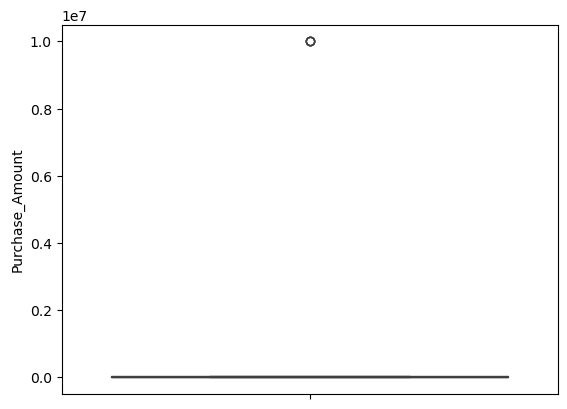

In [377]:
sns.boxplot(df["Purchase_Amount"])

In [387]:
df.describe().round()

,Age,Purchase_Amount,Feedback_Score,Phone_Number
count,9163.0,9163.0,9163.0,9.163000e+03
mean,43.0,29014.0,5.0,4.984675e+09
std,14.0,208830.0,3.0,2.902568e+09
min,3.0,-500.0,1.0,9.208990e+05
25%,32.0,13880.0,2.0,2.449018e+09
50%,43.0,24275.0,5.0,5.001842e+09
75%,55.0,35654.0,8.0,7.510713e+09
max,69.0,9999999.0,10.0,9.994402e+09


In [392]:
from scipy import stats
z_scores = np.abs(stats.zscore(df[['Purchase_Amount']]))
df_final = df[~(z_scores>3).any(axis=1)]
df = df_final

In [393]:
df.shape

(9159, 12)

In [394]:
df.describe()

,Age,Purchase_Amount,Feedback_Score,Phone_Number
count,9159.000000,9159.000000,9159.000000,9.159000e+03
mean,43.414569,24659.241511,5.137788,4.985519e+09
std,14.213290,13613.632403,2.910736,2.902474e+09
min,3.000000,-500.000000,1.000000,9.208990e+05
25%,32.000000,13877.500000,2.000000,2.449637e+09
50%,43.000000,24275.000000,5.000000,5.004593e+09
75%,55.000000,35623.000000,8.000000,7.511722e+09
max,69.000000,49992.000000,10.000000,9.994402e+09


<Axes: ylabel='Purchase_Amount'>

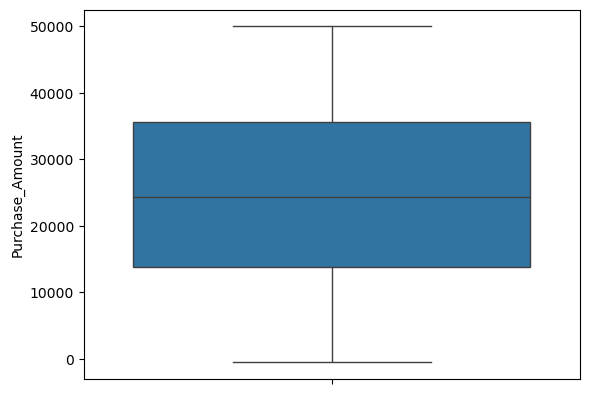

In [404]:
sns.boxplot(df["Purchase_Amount"])

In [405]:
df.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64